In [21]:
# env 설정

from dotenv import load_dotenv
import os

load_dotenv(override=True)

api_key = os.getenv("OPENAI_API_KEY")
g_api_key = os.getenv("GEMINI_API_KEY")
t_api_key = os.getenv("TAVILY_API_KEY")

default_model = os.getenv("OPENAI_DEFAULT_MODEL")
g_default_model = os.getenv("GEMINI_DEFAULT_MODEL")

upstage_api_key = os.getenv("UPSTAGE_API_KEY")

gocamping_api_key = os.getenv("GOCAMPING_API_KEY")

from openai import OpenAI

client = OpenAI()
# print(g_default_model)

In [22]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model=default_model)

# RAG(검생 증강)

## chroma DB CRUD

AI 애플리케이션을 위한 **경량 벡터 데이터베이스**로, 대량의 임베딩 벡터 데이터를 효율적으로 저장하고 유사도 기반 검색을 수행하는 데 최적화

- Chroma는 규모가 크지 않은 데이터에 적합하고, 개발자가 빠르게 프로토타입을 제작하기 좋다. 
대규모 및 복잡도 높은 데이터셋은 Milvus, Pinecone 같은 대안 벡터 DB와 비교해 선택할 수 있다.

### Chroma DB 주요 특징

- **벡터 데이터 저장 및 검색 특화**: 기존 관계형 DB와 달리 고차원 임베딩 벡터를 빠르게 비교하고 검색할 수 있음
  
- **유사도 검색(Similarity Search)** 지원: 코사인 유사도, 유클리드 거리 등을 사용해 가장 비슷한 벡터(문서, 이미지 등)를 신속히 찾음
  
- **경량화 및 로컬 실행 가능**: 데스크톱, 노트북 같은 로컬 환경에서도 빠르게 실행 가능
  
- **클라우드 확장성**: 서비스 규모에 맞게 클라우드 환경으로도 확장 가능
  
- **오픈소스**: Apache 2.0 라이선스 하에 공개되어 누구나 활용 및 수정 가능
  
- 별도의 인증 없이 로컬에서 바로 사용 가능
  
- **persist_directory** 옵션을 사용하면, 벡터DB를 디스크에 저장/복원할 수 있다.
  
- **as_retriever()**로 검색기 생성, **RetrievalQA**로 LLM과 결합해 RAG 질의 응답도 쉽게 구현할 수 있다.
  
- 다양한 임베딩 모델(OpenAI, HuggingFace 등)과 연동 가능하다.

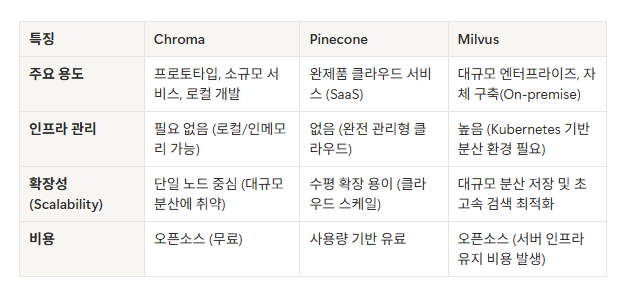

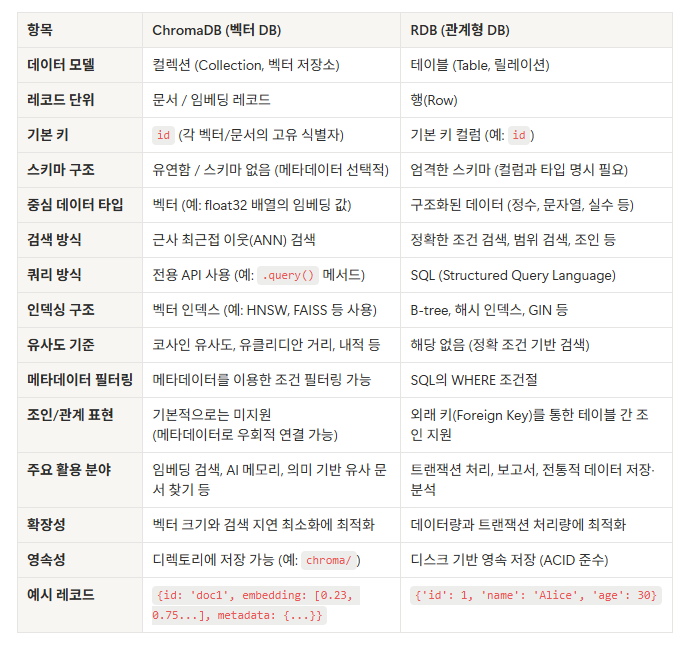

In [23]:
import chromadb

client = chromadb.PersistentClient(path='./my_Chroma_DB')

collection = client.get_or_create_collection(name="my_collection")

## 추가

In [24]:
collection.add(
    documents=['apple','banana','orange','boat'],
    ids = ['1','2','3','4'], # 키 값
    metadatas=[{'type':'fruit'},{'type':'fruit'},{'type':'fruit'},{'type':'vehicle'}] #딕셔너리 타입/그에 대한 정보
)

In [25]:
collection.add(
    documents=['lion','dog','cat','monkey','strawberry','watermelon'],
    ids = ['7','8','9','10','5','6'], # 키 값
    metadatas=[{'type':'animal'},{'type':'animal'},{'type':'animal'},{'type':'animal'},{'type':'fruit'},{'type':'fruit'}] #딕셔너리 타입/그에 대한 정보
)

In [26]:
collection.add(
    documents=['노재희','최지현','박혜준'],
    ids = ['11','12','13'], # 키 값
    metadatas=[{'type':'human'},{'type':'human'},{'type':'princess'}] #딕셔너리 타입/그에 대한 정보
)

## 조회

In [27]:
# 1.데이터 전체 조회
data = collection.get()
print(data)


data = collection.get(ids=['2'])
print(data)

data = collection.get(where={'type':'fruit'})
print(data)

{'ids': ['1', '2', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '3'], 'embeddings': None, 'documents': ['apple', 'banana uqdated', 'boat', 'strawberry', 'watermelon', 'lion', 'dog', 'cat', 'monkey', '노재희', '최지현', '박혜준', 'orange'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'type': 'fruit'}, {'type': 'fruit'}, {'type': 'vehicle'}, {'type': 'fruit'}, {'type': 'fruit'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'human'}, {'type': 'human'}, {'type': 'princess'}, {'type': 'fruit'}]}
{'ids': ['2'], 'embeddings': None, 'documents': ['banana uqdated'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'type': 'fruit'}]}
{'ids': ['1', '2', '5', '6', '3'], 'embeddings': None, 'documents': ['apple', 'banana uqdated', 'strawberry', 'watermelon', 'orange'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'type': 'fruit'}, {'type': 'fruit

In [28]:
data = collection.query(query_texts=['박혜준'], n_results=2)
print(data)

{'ids': [['12', '13']], 'embeddings': None, 'documents': [['최지현', '박혜준']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'type': 'human'}, {'type': 'princess'}]], 'distances': [[0.0, 0.0]]}


## 수정(업데이트)

In [29]:
collection.update(
    ids=['2'],
    documents=['banana uqdated'],
    metadatas=[{'type':'fruit'}]
)

In [30]:
data = collection.get()
print(data)

{'ids': ['1', '2', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '3'], 'embeddings': None, 'documents': ['apple', 'banana uqdated', 'boat', 'strawberry', 'watermelon', 'lion', 'dog', 'cat', 'monkey', '노재희', '최지현', '박혜준', 'orange'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'type': 'fruit'}, {'type': 'fruit'}, {'type': 'vehicle'}, {'type': 'fruit'}, {'type': 'fruit'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'human'}, {'type': 'human'}, {'type': 'princess'}, {'type': 'fruit'}]}


## 삭제(딜리트)

In [31]:
collection.delete(
    ids=['3']
)

{'deleted': 1}

In [32]:
data = collection.get()
print(data)

{'ids': ['1', '2', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13'], 'embeddings': None, 'documents': ['apple', 'banana uqdated', 'boat', 'strawberry', 'watermelon', 'lion', 'dog', 'cat', 'monkey', '노재희', '최지현', '박혜준'], 'uris': None, 'included': ['metadatas', 'documents'], 'data': None, 'metadatas': [{'type': 'fruit'}, {'type': 'fruit'}, {'type': 'vehicle'}, {'type': 'fruit'}, {'type': 'fruit'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'animal'}, {'type': 'human'}, {'type': 'human'}, {'type': 'princess'}]}


# 데이터로더(DataLoader)
- Document Loaders

In [33]:
from langchain_community.document_loaders import TextLoader, PyPDFLoader

text_loader = TextLoader('data.txt',encoding='utf-8')
docs = text_loader.load()
print(docs)

pdf_loader = PyPDFLoader('data.pdf')
pdf_docs = pdf_loader.load()
pdf_docs

[Document(metadata={'source': 'data.txt'}, page_content='프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과 루브르 박물관이 유명하다.\n\n독일의 수도는 베를린이다. 베를린은 역사적으로 중요한 도시이며, 베를린 장벽으로 유명하다.\n\n일본의 수도는 도쿄이다. 도쿄는 기술과 문화의 중심지로, 애니메이션과 음식 문화가 발달해 있다.\n\n영국의 수도는 런던이다. 런던은 전통과 현대가 공존하는 도시로, 빅벤과 타워 브리지가 유명하다.\n\n이탈리아의 수도는 로마이다. 로마는 고대 역사의 숨결이 살아 숨 쉬는 도시로, 콜로세움과 트레비 분수가 유명하다.\n\n미국의 수도는 워싱턴 D.C.이다. 워싱턴 D.C.는 세계 정치와 외교의 중심지로, 백악관과 링컨 기념관이 유명하다.\n\n호주의 수도는 캔버라이다. 캔버라는 계획적으로 조성된 행정 도시이며, 국회의사당과 아름다운 인공 호수인 벌리 그리핀 호수가 유명하다.\n\n스페인의 수도는 마드리드이다. 마드리드는 정열과 예술의 도시로, 프라도 미술관과 화려한 왕궁이 유명하다.')]


[Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3189', 'creationdate': '2026-06-19T14:02:13+09:00', 'author': 'grovy', 'moddate': '2026-06-19T14:02:13+09:00', 'pdfversion': '1.4', 'source': 'data.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과 루브르 박물관이 유명하다.독일의 수도는 베를린이다. 베를린은 역사적으로 중요한 도시이며, 베를린 장벽으로 유명하다.일본의 수도는 도쿄이다. 도쿄는 기술과 문화의 중심지로, 애니메이션과 음식 문화가 발달해 있다.영국의 수도는 런던이다. 런던은 전통과 현대가 공존하는 도시로, 빅벤과 타워 브리지가 유명하다.이탈리아의 수도는 로마이다. 로마는 고대 역사의 숨결이 살아 숨 쉬는 도시로, 콜로세움과 트레비 분수가 유명하다.미국의 수도는 워싱턴 D.C.이다. 워싱턴 D.C.는 세계 정치와 외교의 중심지로, 백악관과 링컨 기념관이 유명하다.호주의 수도는 캔버라이다. 캔버라는 계획적으로 조성된 행정 도시이며, 국회의사당과 아름다운 인공 호수인 벌리 그리핀 호수가 유명하다.스페인의 수도는 마드리드이다. 마드리드는 정열과 예술의 도시로, 프라도 미술관과 화려한 왕궁이 유명하다.')]

In [34]:
from langchain_community.document_loaders import WebBaseLoader

docs = text_loader.load()
print(docs)

pdf_loader = PyPDFLoader('data.pdf')
pdf_docs = pdf_loader.load()
print(pdf_docs)

web_loader=WebBaseLoader('https://www.naver.com/')
web_docs = web_loader.load()
print(web_docs)

[Document(metadata={'source': 'data.txt'}, page_content='프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과 루브르 박물관이 유명하다.\n\n독일의 수도는 베를린이다. 베를린은 역사적으로 중요한 도시이며, 베를린 장벽으로 유명하다.\n\n일본의 수도는 도쿄이다. 도쿄는 기술과 문화의 중심지로, 애니메이션과 음식 문화가 발달해 있다.\n\n영국의 수도는 런던이다. 런던은 전통과 현대가 공존하는 도시로, 빅벤과 타워 브리지가 유명하다.\n\n이탈리아의 수도는 로마이다. 로마는 고대 역사의 숨결이 살아 숨 쉬는 도시로, 콜로세움과 트레비 분수가 유명하다.\n\n미국의 수도는 워싱턴 D.C.이다. 워싱턴 D.C.는 세계 정치와 외교의 중심지로, 백악관과 링컨 기념관이 유명하다.\n\n호주의 수도는 캔버라이다. 캔버라는 계획적으로 조성된 행정 도시이며, 국회의사당과 아름다운 인공 호수인 벌리 그리핀 호수가 유명하다.\n\n스페인의 수도는 마드리드이다. 마드리드는 정열과 예술의 도시로, 프라도 미술관과 화려한 왕궁이 유명하다.')]
[Document(metadata={'producer': 'Hancom PDF 1.3.0.550', 'creator': 'Hwp 2024 13.0.0.3189', 'creationdate': '2026-06-19T14:02:13+09:00', 'author': 'grovy', 'moddate': '2026-06-19T14:02:13+09:00', 'pdfversion': '1.4', 'source': 'data.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과 루브르 박물관이 유명하다.독일의 수도는 베를린이다. 베를린은 역사적으로 중요한 도시이며, 베를린 장벽으로 유명하다.일본의 수도는 도쿄이다. 

# ==========================================

## Document Transformer => 청킹

In [35]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=10)
documents = splitter.split_documents(docs)
print(len(documents))

for doc in documents:
    print(doc)

16
page_content='프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과' metadata={'source': 'data.txt'}
page_content='하나로, 에펠탑과 루브르 박물관이 유명하다.' metadata={'source': 'data.txt'}
page_content='독일의 수도는 베를린이다. 베를린은 역사적으로 중요한 도시이며, 베를린 장벽으로' metadata={'source': 'data.txt'}
page_content='베를린 장벽으로 유명하다.' metadata={'source': 'data.txt'}
page_content='일본의 수도는 도쿄이다. 도쿄는 기술과 문화의 중심지로, 애니메이션과 음식 문화가 발달해' metadata={'source': 'data.txt'}
page_content='문화가 발달해 있다.' metadata={'source': 'data.txt'}
page_content='영국의 수도는 런던이다. 런던은 전통과 현대가 공존하는 도시로, 빅벤과 타워 브리지가' metadata={'source': 'data.txt'}
page_content='타워 브리지가 유명하다.' metadata={'source': 'data.txt'}
page_content='이탈리아의 수도는 로마이다. 로마는 고대 역사의 숨결이 살아 숨 쉬는 도시로, 콜로세움과' metadata={'source': 'data.txt'}
page_content='콜로세움과 트레비 분수가 유명하다.' metadata={'source': 'data.txt'}
page_content='미국의 수도는 워싱턴 D.C.이다. 워싱턴 D.C.는 세계 정치와 외교의 중심지로,' metadata={'source': 'data.txt'}
page_content='외교의 중심지로, 백악관과 링컨 기념관이 유명하다.' metadata={'source': 'data.txt'}
page_content='호주의 수도는 캔버라이다

#### embed_query  ⇒ 단일 문장 임베딩

In [36]:
from langchain_openai import OpenAIEmbeddings

#(3) 임베딩 모델 설정 (OpenAIEmbeddings 사용)
embedding_model = OpenAIEmbeddings()

query = "프랑스의 수도는 파리이다. 파리는 유럽에서 가장 인기 있는 관광 도시 중 하나로, 에펠탑과 루브르 박물관이 유명하다."
# embed_query 메서드로 단일 문장을 벡터(숫자 리스트)로 변환함
vector = embedding_model.embed_query(query)  
print(len(vector))  # 벡터 차원 출력 (보통 OpenAI 임베딩 모델 기준 1536차원의 벡터 (숫자목록))
print(vector)       # 벡터 값(실수 리스트) 출력

1536
[0.01079975999891758, -0.0028549989219754934, 0.011426389217376709, -0.044017497450113297, 0.003957993816584349, 0.01909300498664379, -0.017852535471320152, 0.016087742522358894, 0.008900690823793411, -0.01069105975329876, -0.03238010033965111, 0.005479807499796152, 0.004981061909347773, -0.025845251977443695, -0.017366576939821243, -0.017072444781661034, 0.018274549394845963, -0.0194510780274868, 0.005319952964782715, 0.0015266090631484985, 0.01072942465543747, -0.017021292820572853, 0.0034304745495319366, 0.0002773473097477108, 0.0036798473447561264, 0.017673498019576073, 0.013824204914271832, -0.003942008595913649, -0.011573455296456814, -0.003858884098008275, 0.003910037688910961, 0.0016464998479932547, -0.017660709097981453, -0.02246912755072117, 0.001958215842023492, 0.005598099436610937, 0.003259430406615138, -0.00500663835555315, -0.00013717502588406205, -6.439132994273677e-05, -0.007212628610432148, -0.012110565789043903, 0.01900348626077175, -0.005508581176400185, 0.0093

#### embed_documents  ⇒ 다중 문서 일괄 임베딩

In [37]:
from langchain_openai import OpenAIEmbeddings

# (3) 임베딩 모델 설정: OpenAI에서 제공하는 임베딩 모델을 LangChain 인터페이스로 불러옴
embedding_model = OpenAIEmbeddings()

# 다수 문서에서 텍스트만 추출해 리스트 생성 (docs는 Document 객체 리스트)
doc_texts = [doc.page_content for doc in docs]

# embed_documents 메서드로 여러 문서 텍스트를 벡터 형태로 일괄 변환함
vector = embedding_model.embed_documents(doc_texts)
print(len(vector))  # 변환된 벡터 리스트 개수 (문서 개수와 동일)
print(vector)       # 각 문서별 임베딩 벡터 리스트 출력

1
[[0.006049421150237322, 0.008100736886262894, 0.016057750210165977, -0.032115500420331955, -0.0143200121819973, 0.02835257723927498, -0.03642718493938446, 0.020134249702095985, 0.0006916656857356429, -0.023074032738804817, -0.020016659051179886, 0.002784628188237548, -0.009348511695861816, -0.00661777937784791, -0.019075928255915642, 3.1924209906719625e-05, 0.018579430878162384, -0.016789430752396584, -0.007643437013030052, 0.010661615058779716, 0.001215110532939434, -0.003310522763058543, 0.01833118312060833, -0.0028646555729210377, 0.005082558840513229, 0.028613891452550888, 0.028195789083838463, -0.008185663260519505, -0.003348086727783084, -0.009315847419202328, -0.002660504076629877, 0.005487595684826374, -0.02040863037109375, -0.02728119120001793, 0.0012028614291921258, 0.015469794161617756, -0.0035604042932391167, -0.009453036822378635, -0.001206127810291946, 0.0014159956481307745, -0.018527168780565262, -0.01274559460580349, 0.003975240513682365, -0.009420372545719147, 0.0044

## VectorDB저장

In [38]:
# 1. 분할기 정의
splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=10)

# 2. 데이터를 잘게 쪼개어 새 변수(documents)에 할당
documents = splitter.split_documents(docs)

# 3. [중요] 원본 docs가 아니라, 잘게 쪼갠 'documents'를 대입하여 저장
vectorstore = Chroma.from_documents(
    documents=documents,  # <--- 잘게 쪼개진 변수명을 넣어줍니다.
    embedding=embeddings_model,
    persist_directory='my_Chroma_DB'
)

NameError: name 'Chroma' is not defined

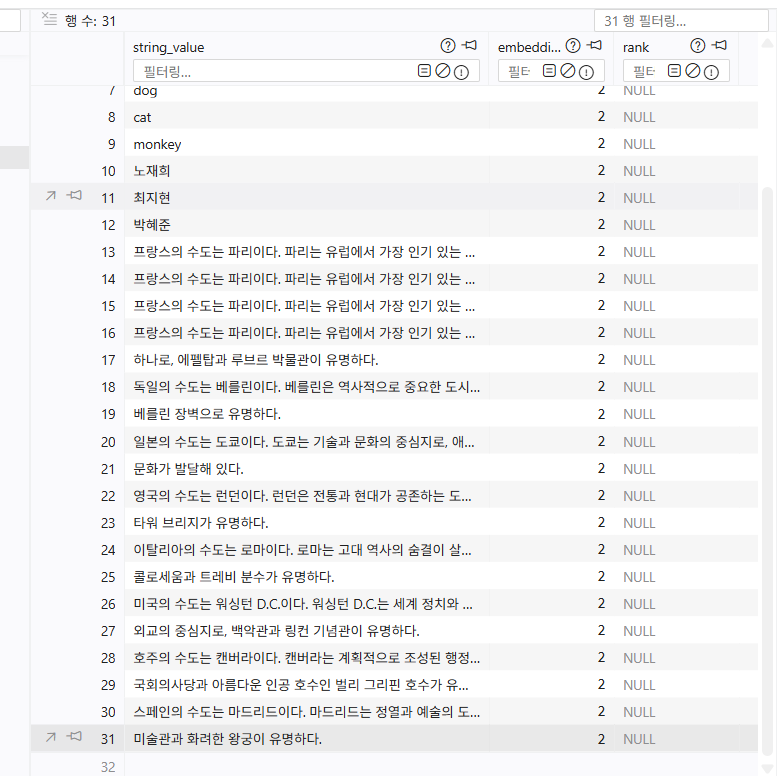

# Retriever 와 LLM 생성과정

### Retriever  ⇒ 검색(Retriever) / RAG Chain 생성 단계

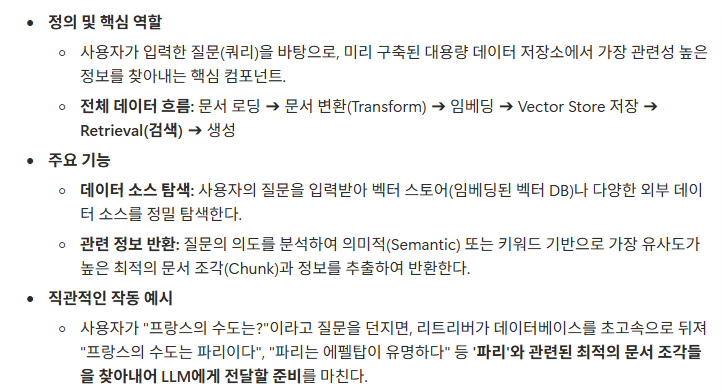

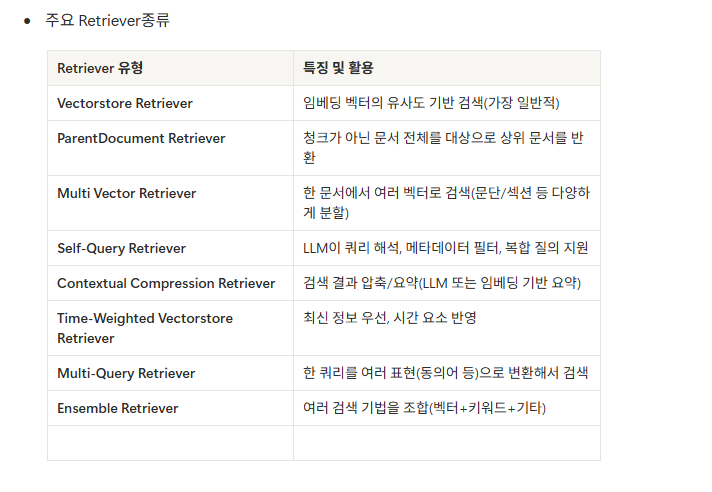

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model = default_model)

#### as_retriever는 벡터스토어(VectorStore) 객체를 리트리버(Retriever) 객체로 변환해주는 LangChain의 메서드.
즉, 벡터 저장소(Chroma, FAISS 등)를 LangChain의 표준화된 검색 인터페이스(Retriever) 로 감싸는 역할을 한다.

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough  
from langchain_core.output_parsers import StrOutputParser

# Retriever 및 LLM 연결
retriever = vectorstore.as_retriever() #벡터 저장소에서 유사 문서 검색 기능 생성




# 생성한 프롬프트 템플릿을 변수(prompt)에 할당
prompt = ChatPromptTemplate.from_template(
    '''다음 문서를 참고해서 답하세요. 만약 문서에 없는 내용이면 지어내지 말고 없다고 답변하세요.
    [참고문서]{context}
    질문: {question}
    '''    
)

def format_docs(documents):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {
        'context': retriever | format_docs, 
        'question': RunnablePassthrough()
    } 
    | prompt 
    | llm 
    | StrOutputParser()
)

In [ ]:
question = "베트남의 수도는 어디인가요?"

ret = rag_chain.invoke(question)
print(ret)

문서에 베트남의 수도에 대한 내용은 없습니다.


## 위키피디아 아이유 페이지 불러오기

In [ ]:
# 실행 결과: 문서에 베트남의 수도에 대한 내용이 없으므로, 답변할 수 없습니다.

url = 'https://ko.wikipedia.org/wiki/아이유'
#mw-content-text

### BeautifulSoup
왜 이름이 '뷰티풀수프(BeautifulSoup)' 일까요?<br>
컴퓨터 프로그래밍 은어로 엉망진창으로 꼬여서 읽기 힘든 웹페이지의 HTML 코드를 '태그 수프(Tag Soup)'라고 부릅니다.<br>
  
이 엉망진창인 태그 수프(Tag Soup)를 인간이 보기 좋은 아름다운(Beautiful) 구조로 변환해 준다는 의미에서 이런 위트 있는 이름이 붙었습니다.



1. 뷰티풀수프가 하는 핵심 역할 3가지
- ① 복잡한 텍스트를 구조화하기 (Parsing)

soup = BeautifulSoup(resp.text, 'html.parser')
구조를 파악해 컴퓨터가 계층적으로 이해할 수 있는 지도(Tree 구조)를 만들어 냅니다. 이 작업을 '파싱(Parsing)'이라고 합니다.

#### 1) 문자열로 데이터 가져오기

In [ ]:
import requests
from bs4 import BeautifulSoup

headers = {'User-Agent': 'Mozilla/5.0'}
url = 'https://ko.wikipedia.org/wiki/%EC%95%84%EC%9D%B4%EC%9C%A0'
resp = requests.get(url, headers=headers)

# 복잡한 html구조를 파싱하기
soup = BeautifulSoup(resp.text, 'html.parser')

# 원하는 상자 정확히 조준하기(searching)
# find(): 조건에 맞는 상자 중 맨 처음 나오는 딱 하나만 찾아와라.
# find_all(): 조건에 맞는 상자를 전부 다 긁어모아서 리스트로 만들어라. (예: 모든 문단 태그인 <p>를 다 가져와라.)
div = soup.find('div', {'id':'mw-content-text'})
#print(div)

# 불순물 제거
for tag in div.find_all(['style', 'script', 'table', 'sup']):
    tag.decompose()

#print(div)
paras = div.find_all('p')
print(paras)


text_list=[]

for p in paras:
    text = p.get_text().strip()
    if text :
        text_list.append(text)

text = '\n'.join(text_list)
print(text)

# ====여기까지 문자열로 불러옴

[<p id="mwCA"><b id="mwCQ">아이유</b>(IU, <span about="#mwt6" data-mw='{"parts":[{"template":{"target":{"wt":"본명","href":"./틀:본명"},"params":{"1":{"wt":"이지은&lt;ref&gt;{{에피소드 인용 |시리즈=[[영웅호걸]] |방송국=[[SBS TV|SBS]] |날짜=2010-09-26 |시리즈번호= |회=11 |시간=14초}}&lt;/ref&gt;"}},"i":0}}]}' id="mwCg" style="font-size: smaller;" typeof="mw:Transclusion"><a href="//ko.wikipedia.org/wiki/본명" rel="mw:WikiLink" title="본명">본명</a>:<span typeof="mw:Entity"> </span></span><span about="#mwt6">이지은</span>, <a href="//ko.wikipedia.org/wiki/1993년" id="mwDw" rel="mw:WikiLink" title="1993년">1993년</a> <a href="//ko.wikipedia.org/wiki/5월_16일" id="mwEA" rel="mw:WikiLink" title="5월 16일">5월 16일</a>~)는 <a href="//ko.wikipedia.org/wiki/대한민국" id="mwEQ" rel="mw:WikiLink" title="대한민국">대한민국</a>의 <a href="//ko.wikipedia.org/wiki/싱어송라이터" id="mwEg" rel="mw:WikiLink" title="싱어송라이터">싱어송라이터</a>, <a href="//ko.wikipedia.org/wiki/작곡가" id="mwEw" rel="mw:WikiLink" title="작곡가">작곡가</a>, <a href="//ko.wikipedia.org/wiki/배우" id="mwFA" rel="mw:Wi

#### 2) chunk단위로 자르기

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
docs = splitter.create_documents([text])
print(docs)

#for doc in docs:
#    print(doc.page_content)


[Document(metadata={}, page_content='아이유(IU, 본명:\xa0이지은, 1993년 5월 16일~)는 대한민국의 싱어송라이터, 작곡가, 배우이다. 2008년, 첫 EP인 로스트 앤 파운드(Lost and Found)를 통해 가수로 데뷔했다.'), Document(metadata={}, page_content='아이유는 2008년 9월 18일 엠넷 M! Countdown에서 데뷔 싱글 "미아"로 데뷔하였고 2008년 9월 23일에 발매된 첫 번째 미니 음반 Lost and Found를 발매하였다. 데뷔 전부터 라디오에서 음악을 알렸던 아이유는 유영석, 유희열, 정재형 등의 많은 음악가로부터 호평을 받았다. 유영석은 "나이가 어린 소녀인데 노래를 너무 잘하고, 음악성이 뛰어난 것 같아서 이 앨범을 추천한다"라고 칭찬하였으며, 정재형은 "앞으로 많은 발전이  가수"라며 기대감을 보였다. 아이유는 음반이 발매되기 전인 2008년 9월 18일에 Mnet 《엠 카운트다운》에서 타이틀곡인 〈미아〉를 불러 첫 데뷔 무대를 가졌다. 타이틀곡 〈미아〉는 이종훈, 민웅식이 공동 작곡한 곡으로 일렉트로닉 사운드에 힙합 리듬이 섞인 하이브리드 팝 발라드이다. 앨범 발매 당시에는 별로 관심을 받지 못하였지만,〈미아〉를 통하여 아이유는 당시 16세의 소녀답지 않은 가창력으로 코러스와 아리아 부분까지 1인 3역을'), Document(metadata={}, page_content="아이유는 당시 16세의 소녀답지 않은 가창력으로 코러스와 아리아 부분까지 1인 3역을 소화해내며 조금씩 대중들에게 얼굴을 알렸다. 그 결과 2008년 10월에 문화체육관광부에서 추진하는 '이달의 우수 신인음반'에 아이유의 Lost and Found가 선정되었다."), Document(metadata={}, page_content='아이유는 2009년 4월 23일에 정규 1집 Growing Up을 발매했다. 이 음반에는 발랄하고 밝은 느낌의 다양한 장르의 곡들이 수록되어 있다. 음반 

#### 3) VectorDB에 저장하기

In [ ]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embedding_model = OpenAIEmbeddings()

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory='my_Chroma_IU'
)
vectorstore.persist()

C:\Users\KDA 25\AppData\Local\Temp\ipykernel_33916\713505454.py:11: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


#### 4) Retriever 과 llm 연결

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough  
from langchain_core.output_parsers import StrOutputParser

# Retriever 및 LLM 연결
retriever = vectorstore.as_retriever() #벡터 저장소에서 유사 문서 검색 기능 생성

# 생성한 프롬프트 템플릿을 변수(prompt)에 할당
prompt = ChatPromptTemplate.from_template(
    '''다음 문서를 참고해서 답하세요. 만약 문서에 없는 내용이면 지어내지 말고 없다고 답변하세요.
    [참고문서]{context}
    질문: {question}
    '''    
)

rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()} | prompt | llm | StrOutputParser()
)

In [ ]:
ret = rag_chain.invoke('아이유는 몇년도에 데뷔했나요?')
print(ret)

아이유는 2008년에 데뷔했습니다.


In [ ]:
ret = rag_chain.invoke("아이유의 노래 '좋은날'은 몇번째 앨범인가요?")
print(ret)

아이유의 노래 '좋은 날'은 세 번째 미니 음반 'REAL'에 수록된 곡입니다.


In [ ]:
ret = rag_chain.invoke("아이유는 어떤 연예인들과 친한가요?")
print(ret)

문서에 아이유가 친한 연예인에 대한 구체적인 내용은 언급되어 있지 않습니다. 따라서 이 질문에 대한 정보는 없습니다.


In [ ]:
ret = rag_chain.invoke("아이유는 수상 경험이 있나요?")
print(ret)

네, 아이유는 여러 차례 수상 경험이 있습니다. 예를 들어, 2016년 한국대중음악상에서 '최우수 팝 음반' 후보로 선정되었고, 2017년 멜론 뮤직 어워드에서 '올해의 TOP10', '싱어송 라이터상', '올해의 앨범상'을 수상하며 3가지 대상을 모두 수상한 기록을 세웠습니다. 또한, 2018년에는 가온차트 뮤직 어워즈에서 5관왕(피처링 곡 포함 시 6관왕)을 기록하며 큰 화제를 모았습니다. 이외에도 여러 시상식에서 다양한 상을 수상한 경력이 있습니다.


In [ ]:
ret = rag_chain.invoke("아이유데뷔곡이 뭐야? 몇년도야?")
print(ret)

아이유의 데뷔곡은 "미아"이며, 2008년에 데뷔하였습니다.


# RAG실습해보기(월드컵 데이터)

In [40]:
from langchain_community.document_loaders import TextLoader, PyPDFLoader

pdf_loader = PyPDFLoader('2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표.pdf')
pdf_docs = pdf_loader.load()
pdf_docs

[Document(metadata={'producer': 'Skia/PDF m126 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표', 'source': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='( 서울 = 뉴스 1) 안영준기자=\' 임시사령탑 \' 김도훈감독이이끄는한국축구대표팀이6 월A 매치2 연전에나설명단을발표했다 .\n손흥민 ( 토트넘 ) 과이강인 ( 파리생제르맹 ) 등주축들이호출됐고오세훈 ( 마치다젤비아 ) 과배준호 ( 스토크 ) 등처음발탁된선수도7 명이나이름을올렸다 .\n대한축구협회 ( KFA) 는27 일2026FIFA 북중미월드컵아시아지역2 차예선싱가포르전 (6 일 ),중국전 (11 일 ) 에나설6 월A 대표팀선수소집명단23 명을발표했다 .\n김도훈감독임시체제로운영되는이번소집에는손흥민 , 이강인 , 이재성등기존주축멤버들이변함없이이름을올렸다 . 동시에변화도적잖다 .\n오세훈 , 배준호 , 황재원 , 최준등연령별대표팀에서활약해온젊은선수들과황인재 ,박승욱 , 하창래등연령별국가대표경력이없는선수까지총7 명이A 대표팀에최초발탁됐다 .\n이밖에부상으로지난3 월소집되지못했던황희찬과엄원상이다시명단에포함됐다 .사우디아라비아에서활약중인정우영은1 년3 개월만에다시태극마크를달았다 .\n김도훈감독은" 시간이촉박한상황에서큰변화를가져오는건어려운사정이있었다 .하지만기존주축선수들의부상이나몸상태등을고려할때대체자원이마련돼야한다는판단에서코칭스태프들과깊이있는회의를통해명단을구성했다 " 고설명했다 .\n이어" 새로운선수들이상당수합류했는데기존의국가대표선수들은기량면에서어떤선수들과도호흡을잘맞출수있는능력이있다 . 전술적인준비를잘해서이번2 경기에서신구조화가잘될수있도

In [41]:
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings_model = OpenAIEmbeddings()
splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=10)

documents = splitter.split_documents(pdf_docs)
print(documents)

# 잘게 쪼갠 'documents'를 대입하여 저장
vectorstore = Chroma.from_documents(
    documents=documents, 
    embedding=embeddings_model,
    persist_directory='my_WorldCup_DB'
)

[Document(metadata={'producer': 'Skia/PDF m126 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표', 'source': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content="( 서울 = 뉴스 1) 안영준기자=' 임시사령탑 ' 김도훈감독이이끄는한국축구대표팀이6 월A"), Document(metadata={'producer': 'Skia/PDF m126 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표', 'source': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='월A 매치2 연전에나설명단을발표했다 .'), Document(metadata={'producer': 'Skia/PDF m126 Google Docs Renderer', 'creator': 'PyPDF', 'creationdate': '', 'title': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표', 'source': '2026 FIFA북중미 월드컵 아시아지역 2차 예선 6월 A대표팀 선수 소집 명단 발표.pdf', 'total_pages': 2, 'page': 0, 'page_label': '1'}, page_content='손흥민 ( 토트넘 ) 과이강인 ( 파리생제

In [43]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough  
from langchain_core.output_parsers import StrOutputParser

# Retriever 및 LLM 연결
retriever = vectorstore.as_retriever() #벡터 저장소에서 유사 문서 검색 기능 생성

# 생성한 프롬프트 템플릿을 변수(prompt)에 할당
prompt = ChatPromptTemplate.from_template(
    '''다음 문서를 참고해서 답하세요. 만약 문서에 없는 내용이면 지어내지 말고 없다고 답변하세요.
    [참고문서]{context}
    질문: {question}
    '''    
)

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = (
    {'context': retriever | format_docs, 'question': RunnablePassthrough()} | prompt | llm | StrOutputParser()
)

In [44]:
ret = rag_chain.invoke('선발에서 제외된 선수 이름은??')
print(ret)

부상으로 제외된 선수 이름은 김민재, 조규성, 설영우입니다.


In [45]:
ret = rag_chain.invoke('소집 선수는 몇 명이니?')
print(ret)

소집 선수는 23명입니다.


In [46]:
ret = rag_chain.invoke('수비수로 뽑힌 선수는 모두 몇 명이고, 이름이 뭐니?')
print(ret)

문서에 따르면 수비수로 뽑힌 선수는 3명입니다. 그 이름은 권경원 (수원 FC), 박승욱 (김천상무), 조유민 (샤르자)입니다.
